# Ejercicio 1 - Modelo SIRS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp

In [2]:
# Definimos las ecuaciones del modelo
def sirs(t, y, beta, tau_I, tau_R):
    s, i = y
    dsdt = - beta * s * i + 1/tau_R * (1 - i - s)
    didt = beta * s * i - 1/tau_I * i
    return [dsdt, didt]

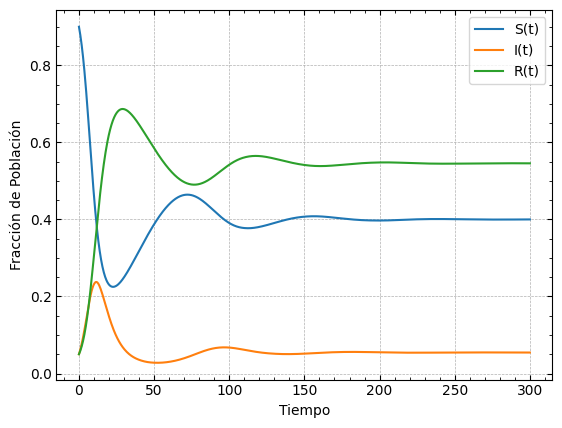

In [3]:
tau_I = 5
tau_R = 50
beta = 0.5
t_span = (0, 300)
y0 = [0.9, 0.05] # En las condiciones iniciales no hay infectados ni recuperados

sol = solve_ivp(sirs, t_span, y0, args=(beta, tau_I, tau_R), dense_output=True)
t = np.linspace(0, 300, 1000)
y = sol.sol(t)

fig, ax = plt.subplots()

ax.plot(t, y[0], label='S(t)')
ax.plot(t, y[1], label='I(t)')
ax.plot(t, 1 - y[0] - y[1], label='R(t)')
ax.legend()
ax.set_xlabel('Tiempo')
ax.set_ylabel('Fracción de Población')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.grid(linestyle='--', linewidth=0.5)
plt.savefig('sirs.pdf')
plt.show()